29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

TASK 1: TRAINING WITH MSE
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0526 - val_loss: 0.0297
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0242 - val_loss: 0.0203
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0181 - val_loss: 0.0162
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0150 - val_loss: 0.0142
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0134 - val_loss: 0.0129
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


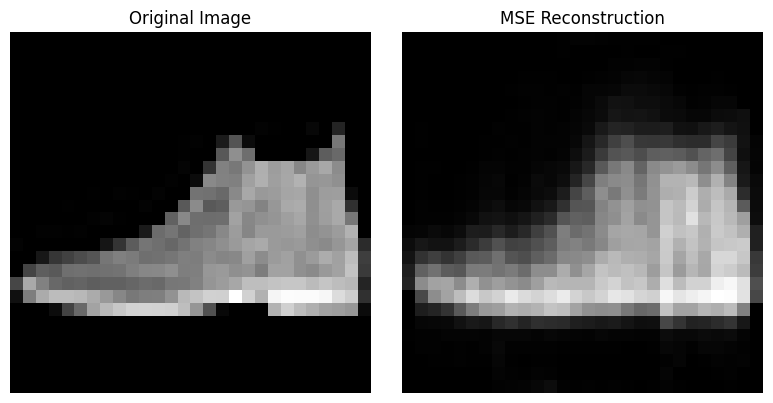


TASK 2: TRAINING WITH BCE
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.3890 - val_loss: 0.3283
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3140 - val_loss: 0.3068
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2983 - val_loss: 0.2951
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2894 - val_loss: 0.2885
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2844 - val_loss: 0.2846
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


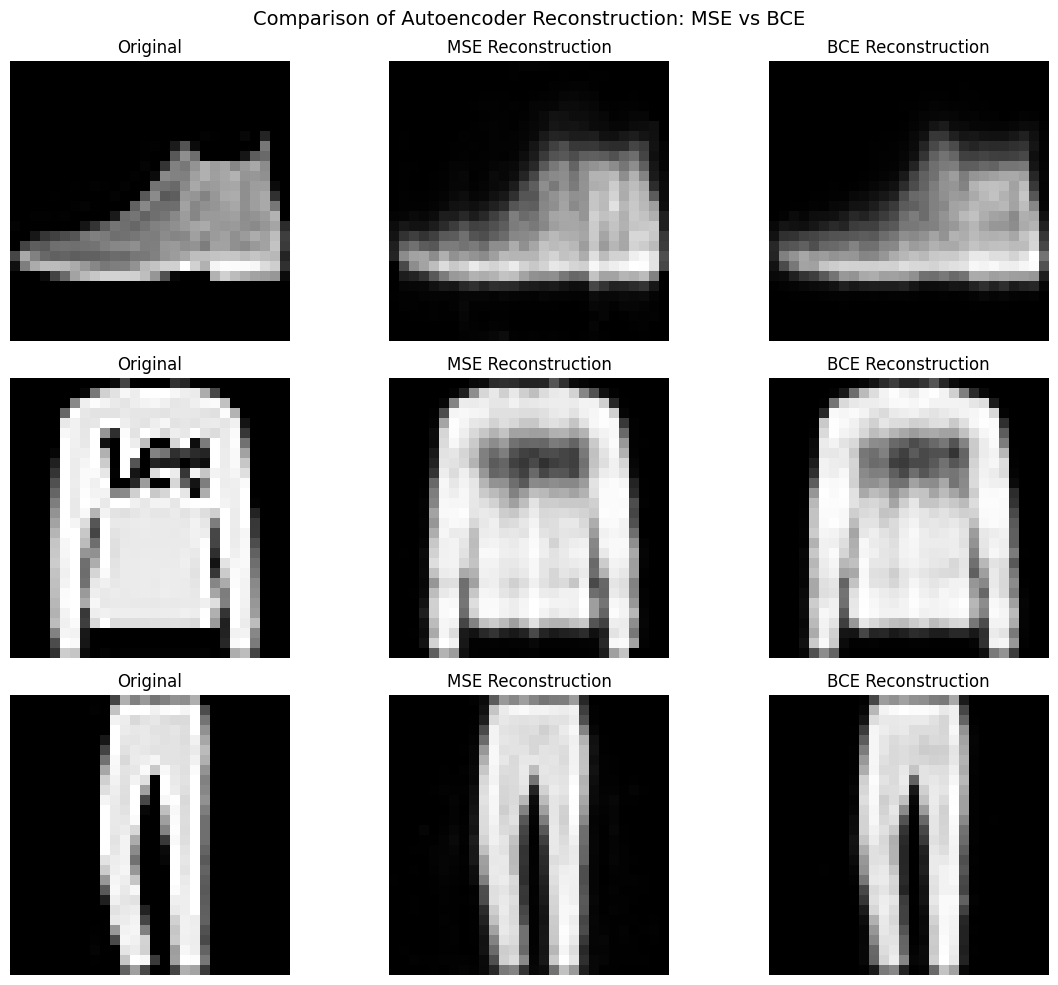


FINAL TEST LOSS
MSE Autoencoder Loss: 0.012893298640847206
BCE Autoencoder Loss: 0.2846148908138275


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# TASK 1: AUTOENCODER USING MEAN SQUARED ERROR (MSE)
# ============================================================

# 1. Load Fashion MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()

# 2. Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. Flatten 28x28 images into 784-dimensional vectors
x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)


# 4. Build the Autoencoder
input_img = keras.Input(shape=(784,))

# Encoder: compress 784 pixels into 64 values
encoded = layers.Dense(64, activation="relu")(input_img)

# Decoder: reconstruct 784 pixels
decoded = layers.Dense(784, activation="sigmoid")(encoded)

# Complete autoencoder
autoencoder_mse = keras.Model(input_img, decoded)


# 5. Compile using Mean Squared Error (MSE)
autoencoder_mse.compile(
    optimizer="adam",
    loss="mse"
)


# 6. Train the MSE Autoencoder
print("\n==============================")
print("TASK 1: TRAINING WITH MSE")
print("==============================")

autoencoder_mse.fit(
    x_train_flat,
    x_train_flat,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat)
)


# 7. Reconstruct test images
reconstructed_mse = autoencoder_mse.predict(x_test_flat)


# 8. Display one original and reconstructed image for Task 1
index = 0

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(x_test[index], cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_mse[index].reshape(28, 28), cmap="gray")
plt.title("MSE Reconstruction")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# TASK 2: AUTOENCODER USING BINARY CROSSENTROPY (BCE)
# ============================================================

# 1. Build a new Autoencoder
input_img_bce = keras.Input(shape=(784,))

# Encoder
encoded_bce = layers.Dense(64, activation="relu")(input_img_bce)

# Decoder
decoded_bce = layers.Dense(784, activation="sigmoid")(encoded_bce)

# Complete autoencoder
autoencoder_bce = keras.Model(input_img_bce, decoded_bce)


# 2. Compile using Binary Crossentropy (BCE)
autoencoder_bce.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)


# 3. Train the BCE Autoencoder
print("\n==============================")
print("TASK 2: TRAINING WITH BCE")
print("==============================")

autoencoder_bce.fit(
    x_train_flat,
    x_train_flat,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat)
)


# 4. Reconstruct test images
reconstructed_bce = autoencoder_bce.predict(x_test_flat)


# ============================================================
# TASK 2: VISUAL COMPARISON FOR 3 TEST IMAGES
# ============================================================

plt.figure(figsize=(12, 10))

for i in range(3):

    # Original image
    plt.subplot(3, 3, i * 3 + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # MSE reconstruction
    plt.subplot(3, 3, i * 3 + 2)
    plt.imshow(
        reconstructed_mse[i].reshape(28, 28),
        cmap="gray"
    )
    plt.title("MSE Reconstruction")
    plt.axis("off")

    # BCE reconstruction
    plt.subplot(3, 3, i * 3 + 3)
    plt.imshow(
        reconstructed_bce[i].reshape(28, 28),
        cmap="gray"
    )
    plt.title("BCE Reconstruction")
    plt.axis("off")


plt.suptitle(
    "Comparison of Autoencoder Reconstruction: MSE vs BCE",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ============================================================
# FINAL LOSS COMPARISON
# ============================================================

mse_loss = autoencoder_mse.evaluate(
    x_test_flat,
    x_test_flat,
    verbose=0
)

bce_loss = autoencoder_bce.evaluate(
    x_test_flat,
    x_test_flat,
    verbose=0
)

print("\n==============================")
print("FINAL TEST LOSS")
print("==============================")
print("MSE Autoencoder Loss:", mse_loss)
print("BCE Autoencoder Loss:", bce_loss)